# DSCI 552 Homework 2

Name: Jingyu Zhang
GitHub Username: jingyuz9-wq 
USC ID: 5744431585

In [8]:
import pandas as pd

In [9]:
import piplite
await piplite.install("openpyxl")

In [10]:
import statsmodels.formula.api as smf

In [11]:
df = pd.read_excel("Folds5x2_pp.xlsx", sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [12]:
df.shape

(9568, 5)

In [13]:
print("number of rows:",  df.shape[0])
print("number of columns:", df.shape[1])

number of rows: 9568
number of columns: 5


The data set contains 9,568 rows and 5 columns.Each row represents one hourly observation from the combined cycle power plant. The columns AT, V, AP, and RH are the four predictor variables, representing ambient temperature, exhaust vacuum, ambient pressure, and relative humidity, respectively. PE is the response variable and represents the net hourly electrical energy output.

In [14]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

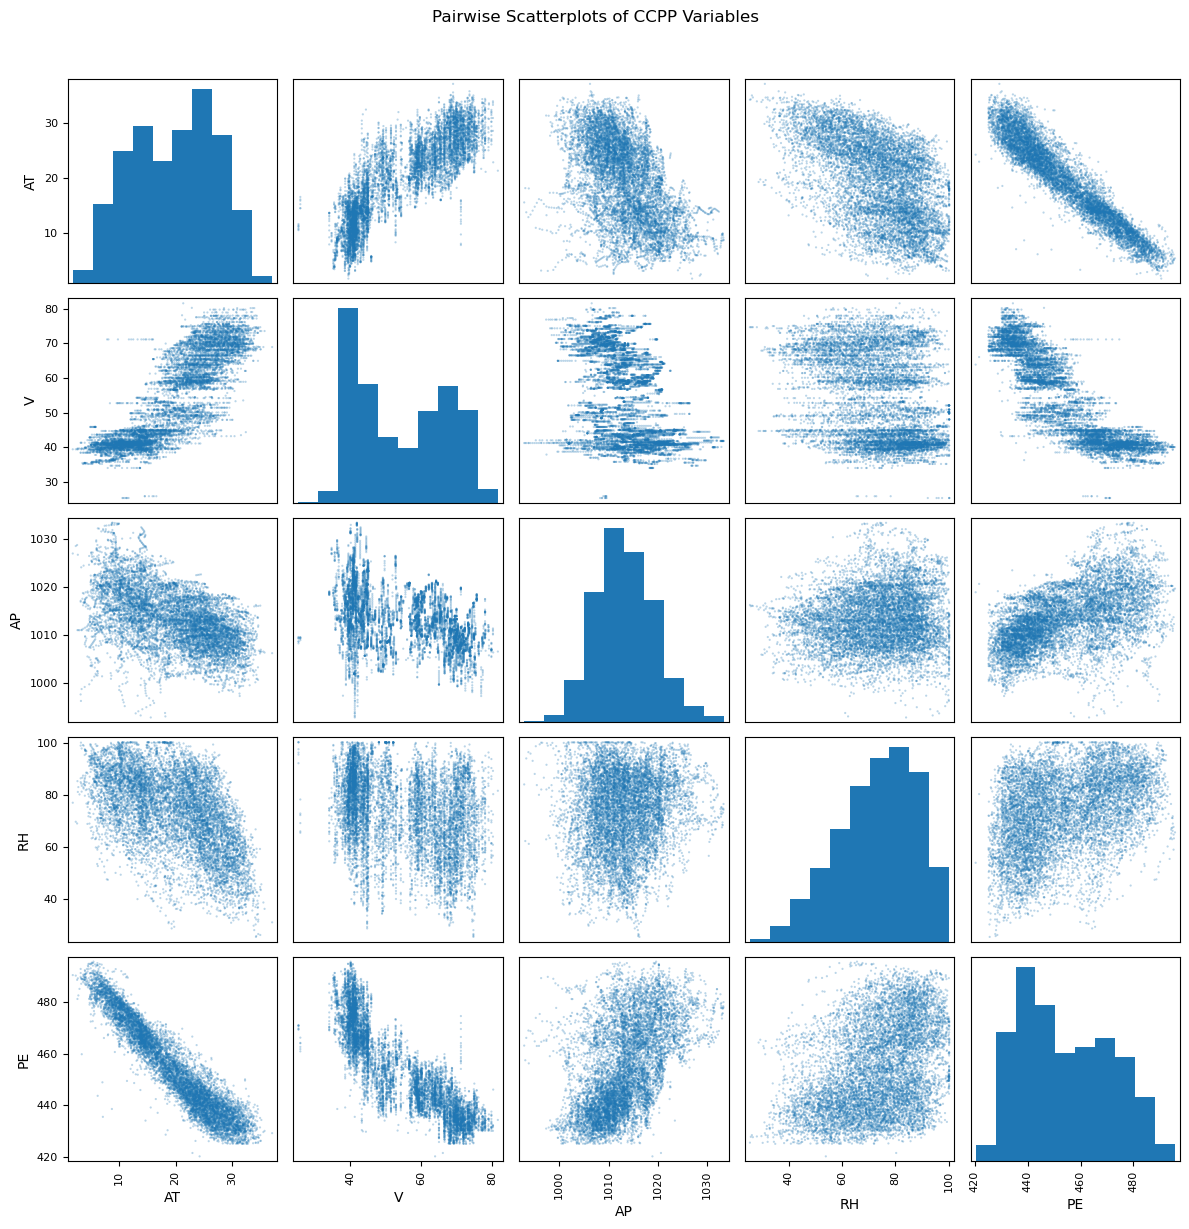

In [15]:
axes = scatter_matrix(
    df,
    figsize=(12, 12),
    diagonal="hist",
    alpha=0.3,
    s=10
)

plt.suptitle("Pairwise Scatterplots of CCPP Variables", y=1.02)
plt.tight_layout()
plt.show()

In [16]:
df.corr().round(3)

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


### 1(b)(ii)

The pairwise scatterplots show that PE has a very strong negative association with AT and a strong negative association with V. In other words, higher ambient temperature and exhaust vacuum tend to be associated with lower electrical energy output. PE has a moderate positive association with AP and a weaker positive association with RH.

There is also a strong positive association between AT and V, indicating that some of the predictor variables are correlated with each other. The scatterplots suggest some curvature and clustering, particularly in the relationships of PE with AT and V. Therefore, a purely linear model may not capture every pattern in the data.

In [17]:
df.describe().round(2)

,AT,V,AP,RH,PE
count,9568.00,9568.00,9568.00,9568.00,9568.00
mean,19.65,54.31,1013.26,73.31,454.37
std,7.45,12.71,5.94,14.60,17.07
min,1.81,25.36,992.89,25.56,420.26
25%,13.51,41.74,1009.10,63.33,439.75
50%,20.34,52.08,1012.94,74.97,451.55
75%,25.72,66.54,1017.26,84.83,468.43
max,37.11,81.56,1033.30,100.16,495.76


In [18]:
range_values = df.max() - df.min()
iqr_values = df.quantile(0.75) - df.quantile(0.25)

print("Range:")
print(range_values.round(2))

print("\nIQR:")
print(iqr_values.round(2))

Range:
AT    35.30
V     56.20
AP    40.41
RH    74.60
PE    75.50
dtype: float64

IQR:
AT    12.21
V     24.80
AP     8.16
RH    21.50
PE    28.68
dtype: float64


In [19]:
summary_table = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
}).round(2)

summary_table

,Mean,Median,Range,Q1,Q3,IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


In [20]:
model_AT = smf.ols(formula="PE ~ AT", data=df).fit()
print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:23:12   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.0

#### Simple Linear Regression: PE versus AT

The fitted regression model is:

$$
\widehat{PE} = 497.0341 - 2.1713\,AT
$$

The estimated slope for AT is -2.1713, indicating that a one-degree Celsius increase in ambient temperature is associated with an average decrease of approximately 2.17 MW in electrical energy output. The p-value for AT is less than 0.001, so the association between AT and PE is statistically significant. The model has an R-squared value of 0.899, meaning that AT alone explains approximately 89.9% of the variability in PE.

In [21]:
model_V = smf.ols(formula="PE ~ V", data=df).fit()
print(model_V.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:23:12   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    517.8015      0.378   1370.218      0.0

#### Simple Linear Regression: PE versus V

The fitted regression model is:

$$
\widehat{PE} = 517.8015 - 1.1681V
$$

The estimated slope for V is -1.1681, indicating that a one-unit increase in exhaust vacuum is associated with an average decrease of approximately 1.17 MW in electrical energy output. The p-value for V is less than 0.001, so the association between V and PE is statistically significant. The R-squared value is 0.757, meaning that V alone explains approximately 75.7% of the variability in PE.

In [22]:
model_AP = smf.ols(formula="PE ~ AP", data=df).fit()
print(model_AP.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:23:12   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1055.2610     25.459    -41.449      0.0

#### Simple Linear Regression: PE versus AP

The fitted regression model is:

$$
\widehat{PE} = -1055.2610 + 1.4899AP
$$

The estimated slope for AP is 1.4899, indicating that a one-unit increase in ambient pressure is associated with an average increase of approximately 1.49 MW in electrical energy output. The p-value for AP is less than 0.001, so the association between AP and PE is statistically significant. The R-squared value is 0.269, meaning that AP alone explains approximately 26.9% of the variability in PE.

In [23]:
model_RH = smf.ols(formula="PE ~ RH", data=df).fit()
print(model_RH.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:23:12   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    420.9618      0.823    511.676      0.0

#### Simple Linear Regression: PE versus RH

The fitted regression model is:

$$
\widehat{PE}=420.9618+0.4557RH
$$

The estimated slope for RH is 0.4557, indicating that a one-unit increase in relative humidity is associated with an average increase of approximately 0.46 MW in electrical energy output. The p-value for RH is less than 0.001, so the association between RH and PE is statistically significant. The R-squared value is 0.152, meaning that RH alone explains approximately 15.2% of the variability in PE.

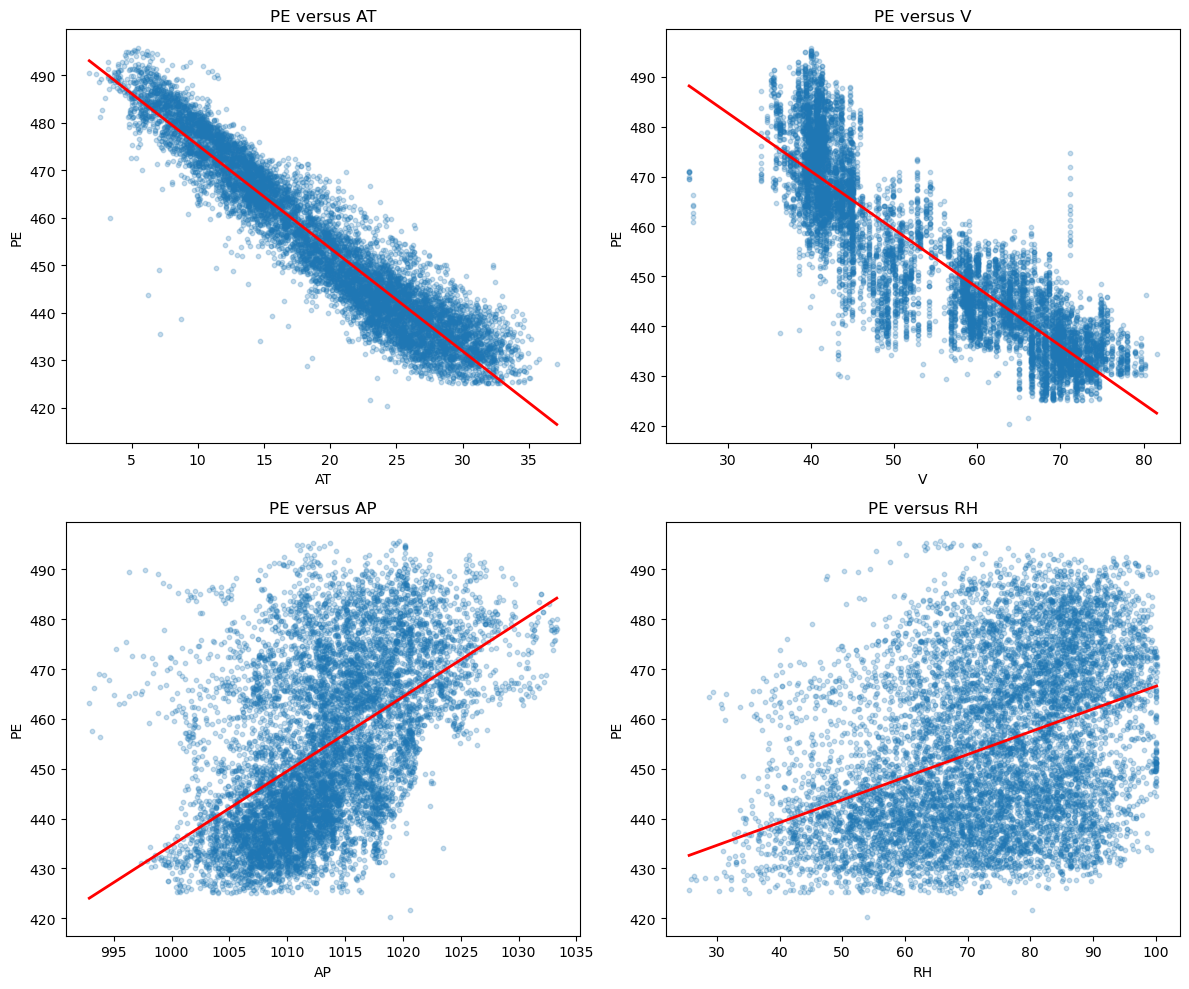

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

predictors = ["AT", "V", "AP", "RH"]
models = [model_AT, model_V, model_AP, model_RH]

for ax, predictor, model in zip(axes.flatten(), predictors, models):
    ax.scatter(
        df[predictor],
        df["PE"],
        alpha=0.25,
        s=10
    )

    x_sorted = df[predictor].sort_values()
    prediction_data = pd.DataFrame({predictor: x_sorted})
    predicted_PE = model.predict(prediction_data)

    ax.plot(
        x_sorted,
        predicted_PE,
        color="red",
        linewidth=2
    )

    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")
    ax.set_title(f"PE versus {predictor}")

plt.tight_layout()
plt.show()

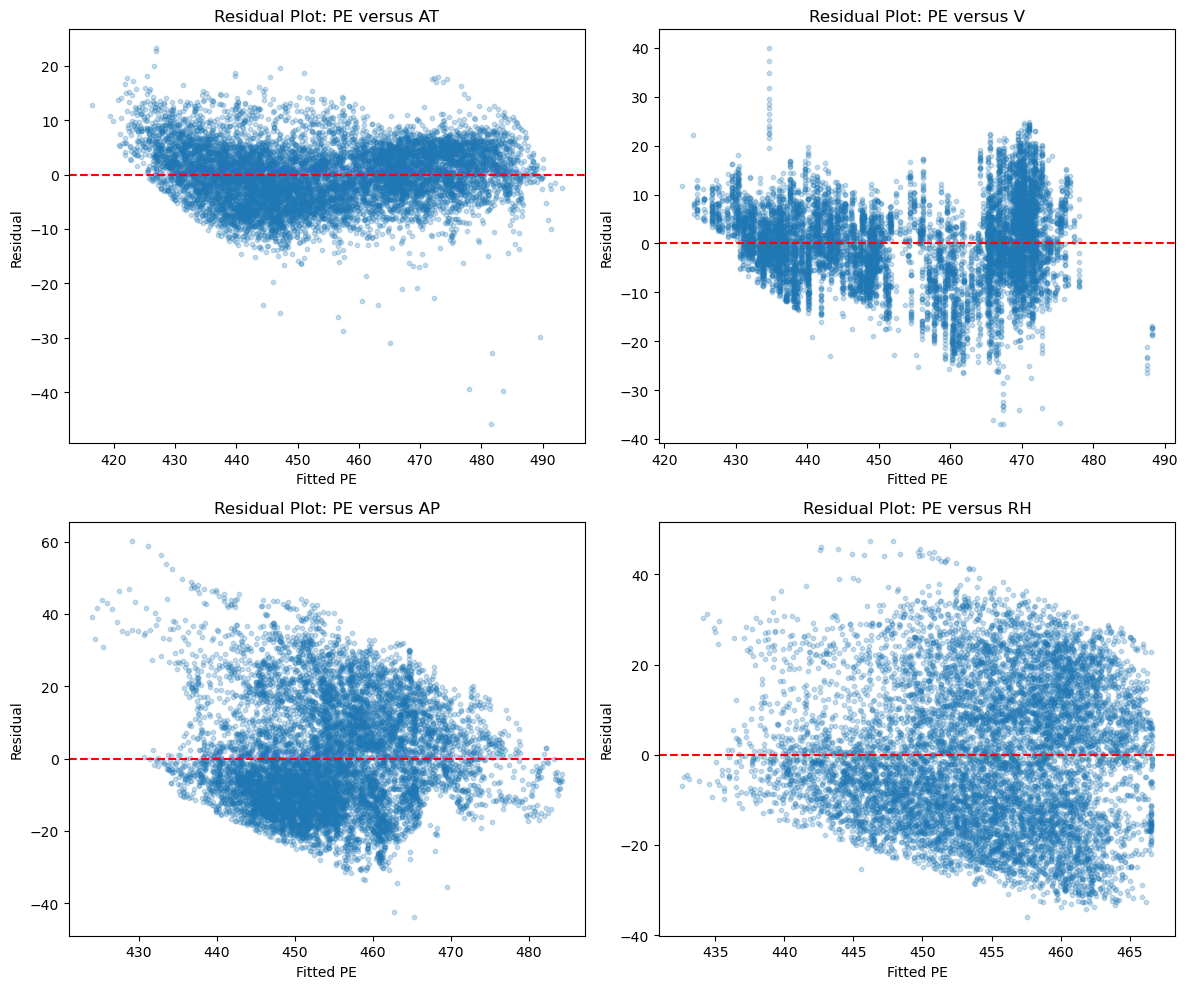

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

predictors = ["AT", "V", "AP", "RH"]
models = [model_AT, model_V, model_AP, model_RH]

for ax, predictor, model in zip(axes.flatten(), predictors, models):
    ax.scatter(
        model.fittedvalues,
        model.resid,
        alpha=0.25,
        s=10
    )

    ax.axhline(
        y=0,
        color="red",
        linestyle="--"
    )

    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Residual")
    ax.set_title(f"Residual Plot: PE versus {predictor}")

plt.tight_layout()
plt.show()

#### Overall Conclusion for Part 1(c)

All four predictors have statistically significant associations with PE, since their p-values are less than 0.001. AT and V have negative associations with PE, whereas AP and RH have positive associations with PE.

Based on the R-squared values, AT is the strongest individual predictor of PE ($R^2=0.899$), followed by V ($R^2=0.757$), AP ($R^2=0.269$), and RH ($R^2=0.152$).

The scatterplots and residual plots show some observations with relatively large residuals. The residual plots also contain systematic patterns, particularly for AP and RH, suggesting that the simple linear models do not capture all patterns in the data. However, there is no clear evidence that these observations are data-entry errors. Therefore, I would retain all observations rather than remove potential outliers solely based on these plots.

In [26]:
model_multiple = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=df
).fit()

print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:23:13   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

#### Multiple Linear Regression

The fitted multiple linear regression model is:

$$
\widehat{PE}
=
454.6093
-1.9775AT
-0.2339V
+0.0621AP
-0.1581RH
$$

The model has an R-squared value of approximately 0.929, indicating that the four predictors together explain approximately 92.9% of the variability in PE.

Holding the other predictors constant, a one-unit increase in AT is associated with an average decrease of approximately 1.98 MW in PE. A one-unit increase in V is associated with an average decrease of approximately 0.234 MW in PE. A one-unit increase in AP is associated with an average increase of approximately 0.062 MW in PE. A one-unit increase in RH is associated with an average decrease of approximately 0.158 MW in PE.

The p-values for AT, V, AP, and RH are all less than 0.001. Therefore, we reject the null hypothesis $H_0:\beta_j=0$ for all four predictors. All four predictors have statistically significant associations with PE in the multiple regression model.

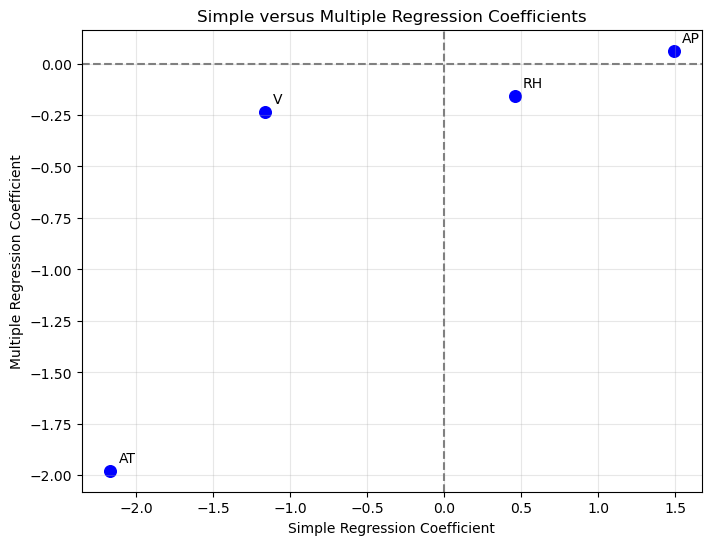

In [27]:
predictors = ["AT", "V", "AP", "RH"]

simple_coefficients = [
    model_AT.params["AT"],
    model_V.params["V"],
    model_AP.params["AP"],
    model_RH.params["RH"]
]

multiple_coefficients = [
    model_multiple.params["AT"],
    model_multiple.params["V"],
    model_multiple.params["AP"],
    model_multiple.params["RH"]
]

plt.figure(figsize=(8, 6))

plt.scatter(
    simple_coefficients,
    multiple_coefficients,
    color="blue",
    s=70
)

for i, predictor in enumerate(predictors):
    plt.annotate(
        predictor,
        (simple_coefficients[i], multiple_coefficients[i]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple versus Multiple Regression Coefficients")

plt.grid(alpha=0.3)
plt.show()

#### Comparison of Simple and Multiple Regression Coefficients

The estimated coefficients from the simple and multiple regression models are:

| Predictor | Simple regression coefficient | Multiple regression coefficient |
|---|---:|---:|
| AT | -2.1713 | -1.9775 |
| V | -1.1681 | -0.2339 |
| AP | 1.4899 | 0.0621 |
| RH | 0.4557 | -0.1581 |

The coefficient for AT remains negative and has a relatively similar magnitude in both models. However, the magnitudes of the coefficients for V and AP become substantially smaller in the multiple regression model. The coefficient for RH changes from positive in the simple regression model to negative in the multiple regression model.

These differences occur because the predictors are correlated with one another. A simple regression coefficient does not account for the effects of the other predictors, whereas each multiple regression coefficient represents the association with PE while holding the other predictors constant. All four predictors remain statistically significant in the multiple regression model.

In [28]:
poly_models = {}

for predictor in ["AT", "V", "AP", "RH"]:
    formula = (
        f"PE ~ {predictor} "
        f"+ I({predictor}**2) "
        f"+ I({predictor}**3)"
    )

    poly_models[predictor] = smf.ols(
        formula=formula,
        data=df
    ).fit()

    print(f"\nPolynomial Regression: PE versus {predictor}")
    print(poly_models[predictor].summary())


Polynomial Regression: PE versus AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:23:14   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    49

#### Polynomial Regression

For each predictor, a cubic polynomial regression model of the following form was fitted:

$$
PE=\beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+\epsilon
$$

For AT, both the quadratic and cubic terms have p-values less than 0.001, providing strong evidence of a nonlinear association between AT and PE.

For V, the quadratic term is not statistically significant, with a p-value of approximately 0.769. However, the cubic term is statistically significant, with a p-value of approximately 0.014. Therefore, there is some evidence of a nonlinear association between V and PE.

For AP, both the quadratic and cubic terms have p-values less than 0.001, providing evidence of a nonlinear association between AP and PE.

For RH, both the quadratic and cubic terms have p-values less than 0.001, providing evidence of a nonlinear association between RH and PE.

Overall, there is evidence of nonlinear association between each predictor and PE. For V, the quadratic term should still be retained because the model contains the higher-order cubic term, following the hierarchy principle.

In [29]:
model_interactions = smf.ols(
    formula="PE ~ (AT + V + AP + RH)**2",
    data=df
).fit()

print(model_interactions.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:23:14   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

#### Pairwise Interaction Model

A linear regression model containing all four main effects and all pairwise interaction terms was fitted:

$$
PE \sim (AT+V+AP+RH)^2
$$

The interaction terms AT:V, AT:RH, and V:AP have p-values less than 0.001 and are statistically significant. The AP:RH interaction is also statistically significant, with a p-value of approximately 0.034.

The AT:AP interaction has a p-value of approximately 0.452, and the V:RH interaction has a p-value of approximately 0.086. Therefore, these two interaction terms are not statistically significant at the 0.05 significance level.

The interaction model has an R-squared value of approximately 0.936. Overall, there is evidence that several interactions between the predictors are associated with PE. The significant interaction terms are AT:V, AT:RH, V:AP, and AP:RH.

In [30]:
# Randomly divide the data into 70% training and 30% testing data
train_df = df.sample(frac=0.7, random_state=42)
test_df = df.drop(train_df.index)

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

Training observations: 6698
Testing observations: 2870


In [31]:
basic_model = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=train_df
).fit()

basic_train_predictions = basic_model.predict(train_df)
basic_test_predictions = basic_model.predict(test_df)

basic_train_mse = (
    (train_df["PE"] - basic_train_predictions) ** 2
).mean()

basic_test_mse = (
    (test_df["PE"] - basic_test_predictions) ** 2
).mean()

print("Basic model train MSE:", round(basic_train_mse, 3))
print("Basic model test MSE:", round(basic_test_mse, 3))

Basic model train MSE: 20.728
Basic model test MSE: 20.873


In [32]:
full_formula = (
    "PE ~ AT + V + AP + RH "
    "+ I(AT**2) + I(V**2) + I(AP**2) + I(RH**2) "
    "+ AT:V + AT:AP + AT:RH "
    "+ V:AP + V:RH + AP:RH"
)

full_complex_model = smf.ols(
    formula=full_formula,
    data=train_df
).fit()

print(full_complex_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7264.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:23:14   Log-Likelihood:                -19187.
No. Observations:                6698   AIC:                         3.840e+04
Df Residuals:                    6683   BIC:                         3.851e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -6449.4381   1437.447     -4.487      0.0

#### Model Improvement Using Nonlinearities and Interactions

The data were randomly divided into a 70% training set containing 6,698 observations and a 30% test set containing 2,870 observations. A random seed of 42 was used to make the split reproducible.

The ordinary multiple linear regression model produced a training MSE of approximately 20.728 and a test MSE of approximately 20.873.

A more complex model containing all main effects, quadratic terms, and pairwise interactions was initially fitted. Based on the p-values calculated using the training data, the AT:AP and V:RH interaction terms and the quadratic term for V were removed because they were not statistically significant. The main effects were retained whenever their corresponding quadratic or interaction terms remained in the model, following the hierarchy principle.

The selected nonlinear and interaction model produced a training MSE of approximately 18.028 and a test MSE of approximately 18.334.

Because the selected model has lower training and test MSEs than the ordinary multiple linear regression model, including the significant nonlinear and interaction terms improves the prediction of PE. The similar training and test MSEs also suggest that the improvement is not caused by severe overfitting.

In [33]:
await piplite.install("scikit-learn")

import numpy as np

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [34]:
features = ["AT", "V", "AP", "RH"]

X_train = train_df[features]
y_train = train_df["PE"]

X_test = test_df[features]
y_test = test_df["PE"]

k_values = range(1, 101)

In [35]:
raw_train_mse = []
raw_test_mse = []

for k in k_values:
    raw_knn = KNeighborsRegressor(n_neighbors=k)
    raw_knn.fit(X_train, y_train)

    raw_train_predictions = raw_knn.predict(X_train)
    raw_test_predictions = raw_knn.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(y_train, raw_train_predictions)
    )

    raw_test_mse.append(
        mean_squared_error(y_test, raw_test_predictions)
    )

best_raw_k = np.argmin(raw_test_mse) + 1

print("Best k for raw features:", best_raw_k)
print(
    "Raw-feature train MSE:",
    round(raw_train_mse[best_raw_k - 1], 3)
)
print(
    "Raw-feature test MSE:",
    round(raw_test_mse[best_raw_k - 1], 3)
)

Best k for raw features: 5
Raw-feature train MSE: 10.174
Raw-feature test MSE: 16.957


In [36]:
scaler = StandardScaler()

# 只使用训练数据计算标准化参数
X_train_scaled = scaler.fit_transform(X_train)

# 使用训练数据得到的参数转换测试数据
X_test_scaled = scaler.transform(X_test)

scaled_train_mse = []
scaled_test_mse = []

for k in k_values:
    scaled_knn = KNeighborsRegressor(n_neighbors=k)
    scaled_knn.fit(X_train_scaled, y_train)

    scaled_train_predictions = scaled_knn.predict(X_train_scaled)
    scaled_test_predictions = scaled_knn.predict(X_test_scaled)

    scaled_train_mse.append(
        mean_squared_error(y_train, scaled_train_predictions)
    )

    scaled_test_mse.append(
        mean_squared_error(y_test, scaled_test_predictions)
    )

best_scaled_k = np.argmin(scaled_test_mse) + 1

print("Best k for normalized features:", best_scaled_k)
print(
    "Normalized-feature train MSE:",
    round(scaled_train_mse[best_scaled_k - 1], 3)
)
print(
    "Normalized-feature test MSE:",
    round(scaled_test_mse[best_scaled_k - 1], 3)
)

Best k for normalized features: 4
Normalized-feature train MSE: 8.342
Normalized-feature test MSE: 15.853


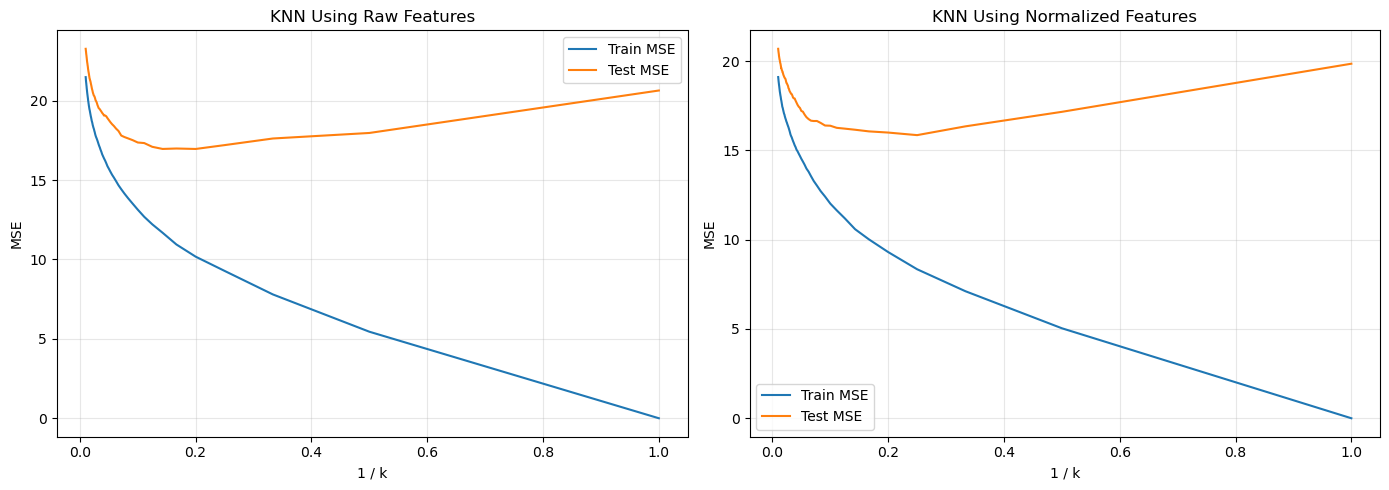

In [37]:
inverse_k = 1 / np.array(list(k_values))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw features
axes[0].plot(
    inverse_k,
    raw_train_mse,
    label="Train MSE"
)

axes[0].plot(
    inverse_k,
    raw_test_mse,
    label="Test MSE"
)

axes[0].set_xlabel("1 / k")
axes[0].set_ylabel("MSE")
axes[0].set_title("KNN Using Raw Features")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Normalized features
axes[1].plot(
    inverse_k,
    scaled_train_mse,
    label="Train MSE"
)

axes[1].plot(
    inverse_k,
    scaled_test_mse,
    label="Test MSE"
)

axes[1].set_xlabel("1 / k")
axes[1].set_ylabel("MSE")
axes[1].set_title("KNN Using Normalized Features")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### KNN Regression

KNN regression was performed for values of $k$ from 1 to 100 using both raw and normalized features.

Using the raw features, the minimum test MSE was approximately 16.957 at $k=5$. The corresponding training MSE was approximately 10.174.

Using the normalized features, the minimum test MSE was approximately 15.853 at $k=4$. The corresponding training MSE was approximately 8.342.

The normalized-feature KNN model performs better because it has the lower test MSE. Normalization is important for KNN because KNN uses distances between observations, and the four predictors have different numerical scales.

When $k$ is very small, the model is highly flexible and may overfit the training data. For example, at $k=1$, the training MSE is zero while the test MSE is much higher. As $k$ becomes very large, the model becomes less flexible and may underfit. The best test performance occurs at an intermediate value of $k$.

#### Comparison of KNN and Linear Regression

The test performances of the best models are summarized below:

| Model | Best parameter | Test MSE |
|---|---:|---:|
| Selected nonlinear and interaction regression model | — | 18.334 |
| KNN using raw features | $k=5$ | 16.957 |
| KNN using normalized features | $k=4$ | 15.853 |

Among the regression models, the selected model containing significant nonlinear and interaction terms has the smallest test MSE of approximately 18.334.

The normalized-feature KNN model with $k=4$ has the smallest overall test MSE of approximately 15.853. Its test MSE is approximately 2.481 lower than that of the selected regression model, representing an improvement of approximately 13.5%.

The raw-feature KNN model also performs better than the selected regression model, but normalization further improves the KNN result. This occurs because KNN is based on distances between observations and is sensitive to differences in the scales of the predictors.

The KNN model can capture local and nonlinear patterns without requiring a specific regression equation. However, the regression model is easier to interpret because it provides explicit coefficients, p-values, and information about the effects of individual predictors.

Based on test MSE, the normalized KNN model with $k=4$ provides the best predictive performance for this dataset.

# 2. ISLR: 2.4.1

For each of parts (a) through (d), indicate whether we would generally expect the performance of a flexible statistical learning method to be better or worse than an inflexible method. Justify your answer.

(a) The sample size n is extremely large, and the number of predictors p is small.
- Large sample size along with small number of predictors can cause the model to underfit if the model is an inflexible statistical learning method. Hence, a flexible model will perform better than an inflexible model.

(b) The number of predictors p is extremely large, and the number of observations n is small.
- Small sample size along with large number of predictors will cause a flexible model to overfit. Hence, a flexible model will perform worse than an inflexible model.

(c) The relationship between the predictors and response is highly non-linear.
- An inflexible model will not be able to adjust to the variances of a highly non-linear model and hence, a flexible model will perform better than a non-flexible model in this case.

(d) The variance of the error terms, i.e. σ2 = Var(ε), is extremely high.
- High variance = More noise which means that a flexible model will overfit. Overfitting is a bad thing and hence, here, a flexible statistical model will perform worse as compared to an inflexible model.


# 3. ISLR: 2.4.7

The table below provides a training data set containing six observations, three predictors, and one qualitative response variable.

(a) Compute the Euclidean distance between each observation and the test point, $X1 = X2 = X3 =0$.

| Obs             | $X_1$           |$X_2$|$X_3$|$Y$|
| -- | -- |-- |--|--|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | -1 | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |




In [38]:
from sklearn.metrics.pairwise import euclidean_distances

In [39]:
X = [[0,3,0], [2,0,0], [0,1,3], [0,1,2], [-1,0,1], [1,1,1]]
testpoint = [[0,0,0]]
euclidean_distance_result = euclidean_distances(X, testpoint)
pd.DataFrame(euclidean_distance_result, index=[1,2,3,4,5,6], columns=[f"euclidean_distance of $Obs_i$ from testpoint"])

,euclidean_distance of $Obs_i$ from testpoint
1,3.000000
2,2.000000
3,3.162278
4,2.236068
5,1.414214
6,1.732051


(b) What is our prediction with $𝐾=1$ ? Why?
- For $K=1$, we predict that the output would be Observation number 5 as it is the closest to the test point and k = 1. So effectively, the prediction of Y is green.

(c) What is our prediction with $K = 3$? Why?
- For $K=3$, we predict that the output would be Observation numbers 2 (Red), 5 (Green) and 6 (Red). Since the majority is 3 Green vs 1 Red, we predict that the output is going to be Red

(d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?
- The value of K is inversely proportional to the flexibility of the module. As K increases, a more linear boundary is achieved. Since the question states that the decision boundary of the problem is highly non-linear, the value of K would this be small.